In [40]:
# ===============================================================
#  GALAXY CLASSIFICATION + DARK MATTER HALO MASS PREDICTION PIPELINE
# ===============================================================
# - CNN for 4-class galaxy morphology (Smooth, Edge-on, Spiral, Barred)
# - Uses CNN morphology probabilities to improve dark matter halo mass prediction
# ===============================================================

import os
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# ===============================================================
# 1️⃣ CLASSIFICATION STAGE
# ===============================================================
mapping_df = pd.read_csv("../data/mapping_combined.csv")
print("Original dataset:", mapping_df.shape)

# 🔧 --- FIX IMAGE PATHS HERE ---
# Ensure paths work from notebooks/ or root directory
mapping_df['image_filename'] = mapping_df['image_filename'].apply(
    lambda p: os.path.join("..", p) if not p.startswith("..") else p
)
mapping_df['image_filename'] = mapping_df['image_filename'].apply(
    lambda p: p.replace("\\", "/")
)

# Verify that at least one image exists
sample_path = mapping_df['image_filename'].iloc[0]
print(f"🔍 Sample image path check:\n{sample_path}\nExists: {os.path.exists(sample_path)}")

# ===============================================================
# Extended label assignment
# ===============================================================
def assign_extended_label_with_confidence(row):
    fractions = {
        0: row.get('t01_smooth_or_features_a01_smooth_fraction', 0),
        1: row.get('t02_edgeon_a04_yes_fraction', 0),
        2: row.get('t04_spiral_a08_spiral_fraction', 0),
        3: row.get('t03_bar_a06_bar_fraction', 0),
    }
    sorted_fracs = sorted(fractions.items(), key=lambda x: x[1], reverse=True)
    max_label, max_frac = sorted_fracs[0]
    second_frac = sorted_fracs[1][1]
    margin = max_frac - second_frac
    return max_label, max_frac, margin

results = mapping_df.apply(assign_extended_label_with_confidence, axis=1)
mapping_df['extended_label'] = results.apply(lambda x: x[0]).astype(int)
mapping_df['max_fraction'] = results.apply(lambda x: x[1])
mapping_df['confidence_margin'] = results.apply(lambda x: x[2])

MIN_CONFIDENCE = 0.5
MIN_MARGIN = 0.15
filtered_df = mapping_df[
    (mapping_df['max_fraction'] >= MIN_CONFIDENCE) & 
    (mapping_df['confidence_margin'] >= MIN_MARGIN)
].copy()

class_names = ["Smooth", "Edge-on", "Spiral", "Barred Spiral"]
print(f"Remaining: {len(filtered_df)} samples")

# ===============================================================
# Dataset Class
# ===============================================================
class GalaxyDataset(Dataset):
    def __init__(self, df, label_type='extended', transform=None):
        self.df = df.reset_index(drop=True)
        self.label_type = label_type
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_filename']
        label = int(self.df.iloc[idx][f'{self.label_type}_label'])
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"❌ Image not found: {img_path}")
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, label

# ===============================================================
# Transforms
# ===============================================================
train_transform = transforms.Compose([
    transforms.Resize((192, 192)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.9,1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((192, 192)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_df, temp_df = train_test_split(filtered_df, test_size=0.2, stratify=filtered_df['extended_label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['extended_label'], random_state=42)

train_dataset = GalaxyDataset(train_df, 'extended', train_transform)
val_dataset   = GalaxyDataset(val_df, 'extended', test_transform)
test_dataset  = GalaxyDataset(test_df, 'extended', test_transform)

class_counts = train_df['extended_label'].value_counts().sort_index().values
weights = 1. / torch.tensor(class_counts, dtype=torch.float)
samples_weights = [weights[train_df.iloc[i]['extended_label']] for i in range(len(train_df))]
sampler = WeightedRandomSampler(samples_weights, num_samples=len(samples_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=24, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=24, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=24, shuffle=False)

# ===============================================================
# Model Setup
# ===============================================================
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🚀 Using device: {device}")

model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.01)

# ===============================================================
# Training Functions
# ===============================================================
def train_one_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader.dataset), 100 * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader.dataset), 100 * correct / total

def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=15):
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.001, total_steps=epochs * len(train_loader), pct_start=0.3
    )
    best_val_acc, history = 0, {'train_acc': [], 'val_acc': []}
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        print(f"Train Acc: {tr_acc:.2f}% | Val Acc: {val_acc:.2f}%")
        history['train_acc'].append(tr_acc); history['val_acc'].append(val_acc)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_galaxy_model.pth')
            print("✅ New best model saved!")
    return history

print("\n🚀 Starting Training...")
history = train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=15)

# ===============================================================
# Evaluation
# ===============================================================
model.load_state_dict(torch.load('best_galaxy_model.pth'))
def evaluate_model(model, loader, device, class_names):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    acc = accuracy_score(y_true, y_pred)
    print(f"\n✅ Test Accuracy: {acc*100:.2f}%")
    print(classification_report(y_true, y_pred, target_names=class_names))
evaluate_model(model, test_loader, device, class_names)

# ===============================================================
# 2️⃣ DARK MATTER HALO MASS PREDICTION STAGE
# ===============================================================
print("\n🌌 Starting Dark Matter Halo Mass Prediction Stage...")

# Step 1: CNN probabilities
full_dataset = GalaxyDataset(filtered_df, 'extended', test_transform)
full_loader = DataLoader(full_dataset, batch_size=32, shuffle=False)
model.eval(); all_probs = []
for images, _ in tqdm(full_loader, desc="Extracting CNN Morphology Probabilities"):
    with torch.no_grad():
        outputs = model(images.to(device))
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.append(probs)
all_probs = np.vstack(all_probs)
filtered_df[['p_smooth','p_edgeon','p_spiral','p_barred']] = all_probs
filtered_df.to_csv("../data/mapping_with_cnn_probs.csv", index=False)
print("✅ Saved CNN morphology probabilities.")

# Step 2: Load merged astrophysical dataset (SDSS + GZ2 + Yang)
merged_df = pd.read_csv("../data/Dark.csv")
print(f"✅ Merged dataset loaded: {merged_df.shape}")

# Step 3: Merge CNN probabilities
merged_final = pd.merge(
    merged_df,
    filtered_df[['dr7objid','p_smooth','p_edgeon','p_spiral','p_barred']],
    on='dr7objid',
    how='left'
)
merged_final.dropna(subset=['logM_halo'], inplace=True)
print(f"✅ Final merged shape: {merged_final.shape}")

# Step 4: Train XGBoost regressors
base_features = [
    'sdss_u','sdss_g','sdss_r','sdss_i','sdss_z',
    'sdss_u_g_color','sdss_g_r_color','sdss_r_i_color','sdss_i_z_color',
    'sdss_fracDeV_r','sdss_concentration_index','sdss_redshift'
]
cnn_features = ['p_smooth','p_edgeon','p_spiral','p_barred']

train_df, test_df = train_test_split(merged_final, test_size=0.2, random_state=42)
y_train, y_test = train_df['logM_halo'], test_df['logM_halo']

def train_and_eval(features, name):
    X_train, X_test = train_df[features], test_df[features]
    model = XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.9, colsample_bytree=0.9, random_state=42
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = mean_squared_error(y_test, preds, squared=False)
    r2 = r2_score(y_test, preds)
    print(f"📊 {name} → RMSE: {rmse:.3f}, R²: {r2:.3f}")
    return rmse, r2

rmse_base, r2_base = train_and_eval(base_features, "Without CNN probabilities")
rmse_cnn,  r2_cnn  = train_and_eval(base_features + cnn_features, "With CNN probabilities")

print("\n🚀 Dark Matter Halo Prediction Results:")
print(f"Without CNN: RMSE={rmse_base:.3f}, R²={r2_base:.3f}")
print(f"With CNN:    RMSE={rmse_cnn:.3f}, R²={r2_cnn:.3f}")
print("\n✅ Pipeline complete: CNN Morphology → Halo Mass Regression finished successfully.")


Original dataset: (7945, 173)
🔍 Sample image path check:
../data/images/1.jpg
Exists: True
Remaining: 6080 samples

🚀 Using device: mps

🚀 Starting Training...

Epoch 1/15


Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [00:01<00:00, 14.04it/s]


Train Acc: 66.74% | Val Acc: 62.83%
✅ New best model saved!

Epoch 2/15


Validation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [00:01<00:00, 14.56it/s]


Train Acc: 71.22% | Val Acc: 66.28%
✅ New best model saved!

Epoch 3/15


...

Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [00:01<00:00, 13.78it/s]



✅ Test Accuracy: 85.20%
               precision    recall  f1-score   support

       Smooth       0.96      0.85      0.90       342
      Edge-on       0.85      0.92      0.89       106
       Spiral       0.84      0.80      0.82       121
Barred Spiral       0.43      0.85      0.57        39

     accuracy                           0.85       608
    macro avg       0.77      0.86      0.80       608
 weighted avg       0.88      0.85      0.86       608


🌌 Starting Dark Matter Halo Mass Prediction Stage...


Extracting CNN Morphology Probabilities: 100%|███████████████████████████████████████████████████████████████████| 190/190 [00:17<00:00, 10.94it/s]


✅ Saved CNN morphology probabilities.
✅ Merged dataset loaded: (28556, 249)


KeyError: "['dr7objid'] not in index"

✅ Dataset loaded: 28556 rows × 249 columns
✅ Feature matrix shape: (28556, 51)
Target range: 7.90 – 12.12

🚀 Training XGBoost model...
✅ Training complete!

📊 PERFORMANCE METRICS
RMSE (dex): 0.053
MAE (dex):  0.033
R² Score:   0.991
Pearson r:  0.995


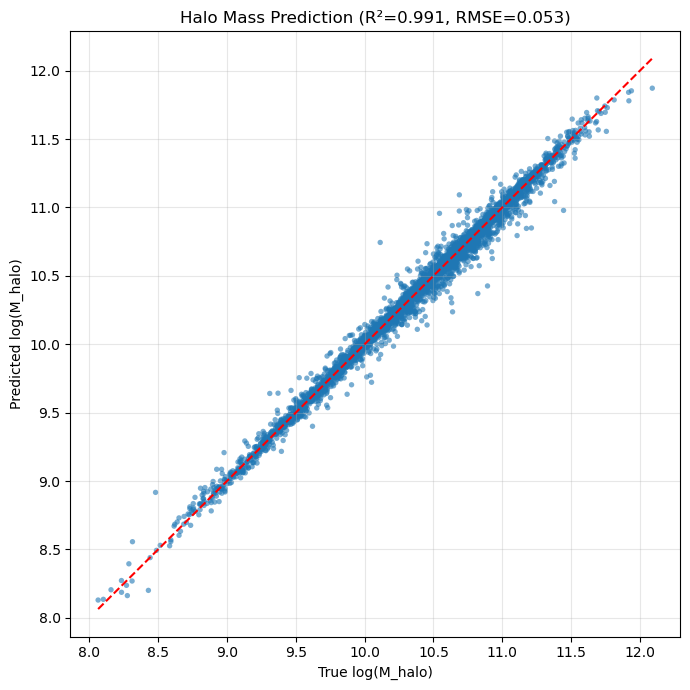

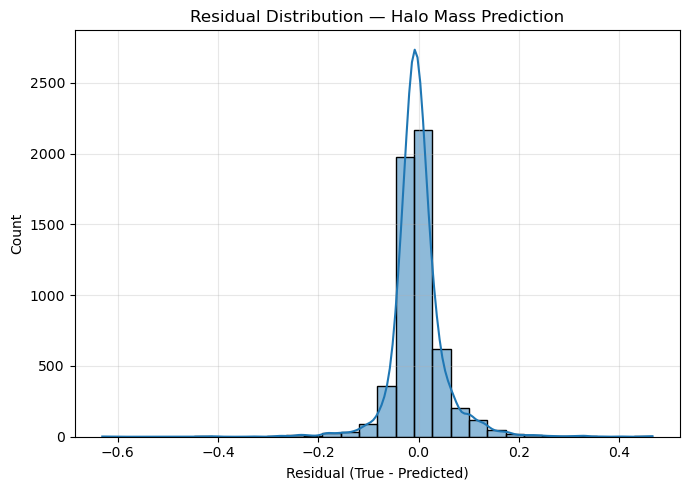

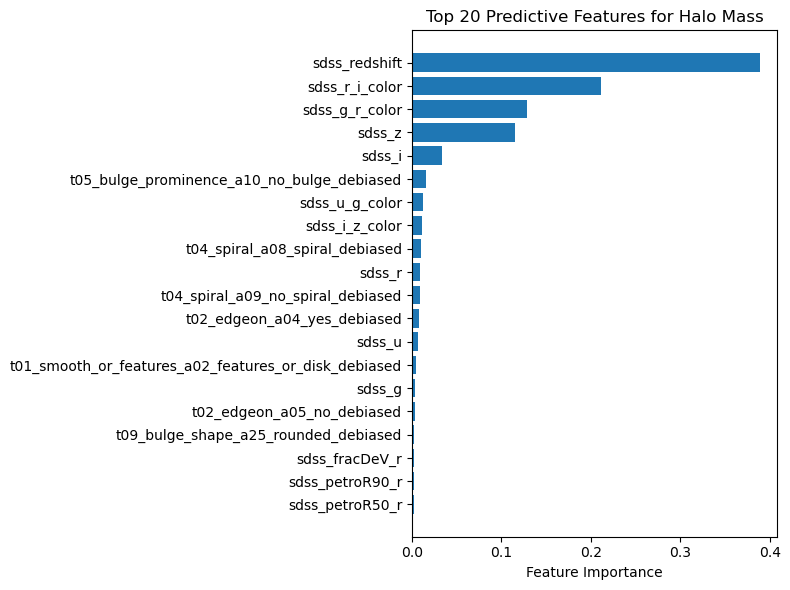


✅ Dark Matter Halo Prediction pipeline complete.


In [43]:
# ============================================================
# 🌌 DARK MATTER HALO MASS PREDICTION — REAL DATA PIPELINE
# GZ2 + SDSS + Yang DR7 Halo Catalog (28k galaxies)
# ============================================================

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings("ignore")

# -------------------------------------------
# 1️⃣ Load the merged dataset
# -------------------------------------------
path = "../data/Dark.csv"  # adjust path if needed
df = pd.read_csv(path)
print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

# -------------------------------------------
# 2️⃣ Select features
# -------------------------------------------
gz2_features = [c for c in df.columns if c.endswith("_debiased")]
sdss_features = [
    "sdss_u","sdss_g","sdss_r","sdss_i","sdss_z",
    "sdss_petroR50_r","sdss_petroR90_r",
    "sdss_fracDeV_r","sdss_concentration_index",
    "sdss_u_g_color","sdss_g_r_color","sdss_r_i_color","sdss_i_z_color",
    "sdss_redshift"
]

# Add CNN features if available
cnn_features = [c for c in ["p_smooth","p_edgeon","p_spiral","p_barred"] if c in df.columns]

X = df[gz2_features + sdss_features + cnn_features].copy()
y = df["logM_halo"].copy()

# -------------------------------------------
# 3️⃣ Handle missing values
# -------------------------------------------
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())
mask = y.notnull()
X, y = X.loc[mask], y.loc[mask]

print(f"✅ Feature matrix shape: {X.shape}")
print(f"Target range: {y.min():.2f} – {y.max():.2f}")

# -------------------------------------------
# 4️⃣ Split train/test
# -------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------------------
# 5️⃣ Train the model (XGBoost)
# -------------------------------------------
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42,
    verbosity=0
)

print("\n🚀 Training XGBoost model...")
model.fit(X_train, y_train)
print("✅ Training complete!")

# -------------------------------------------
# 6️⃣ Evaluate performance
# -------------------------------------------
preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)
corr, _ = pearsonr(y_test, preds)

print("\n📊 PERFORMANCE METRICS")
print(f"RMSE (dex): {rmse:.3f}")
print(f"MAE (dex):  {mae:.3f}")
print(f"R² Score:   {r2:.3f}")
print(f"Pearson r:  {corr:.3f}")

# -------------------------------------------
# 7️⃣ True vs Predicted Scatter
# -------------------------------------------
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=preds, s=15, alpha=0.6, edgecolor='none')
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', lw=1.5)
plt.xlabel("True log(M_halo)")
plt.ylabel("Predicted log(M_halo)")
plt.title(f"Halo Mass Prediction (R²={r2:.3f}, RMSE={rmse:.3f})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------
# 8️⃣ Residual Distribution
# -------------------------------------------
residuals = y_test - preds
plt.figure(figsize=(7,5))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residual (True - Predicted)")
plt.ylabel("Count")
plt.title("Residual Distribution — Halo Mass Prediction")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------
# 9️⃣ Feature Importance
# -------------------------------------------
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(8,6))
plt.barh(np.array(X.columns)[sorted_idx][::-1], importances[sorted_idx][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Predictive Features for Halo Mass")
plt.tight_layout()
plt.show()

# -------------------------------------------
# 🔟 Optional: Visualize random sample images (if image paths exist)
# -------------------------------------------
if "image_filename" in df.columns:
    from PIL import Image
    import random

    print("\n🖼️ Displaying 6 random galaxies (if images available)...")
    sample_rows = df.sample(6, random_state=42)
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        row = sample_rows.iloc[i]
        img_path = row.get("image_filename", None)
        try:
            if img_path and os.path.exists(img_path):
                image = Image.open(img_path)
                ax.imshow(image)
                ax.axis("off")
                pred_mass = model.predict(row[X.columns].to_frame().T)[0]
                true_mass = row["logM_halo"]
                ax.set_title(f"True: {true_mass:.2f} | Pred: {pred_mass:.2f}", fontsize=10)
            else:
                ax.axis("off")
                ax.set_title("⚠️ No Image", fontsize=9)
        except Exception as e:
            ax.axis("off")
            ax.set_title("⚠️ Error loading image", fontsize=9)

    plt.tight_layout()
    plt.show()

print("\n✅ Dark Matter Halo Prediction pipeline complete.")


Original dataset: (7945, 173)
🔍 Checking sample path: ../data/images/1.jpg
Filtered dataset: 6080 samples
🚀 Using device: mps

🚀 Starting training...


Epoch 1/10: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 203/203 [00:44<00:00,  4.56it/s]


Train Acc: 77.01% | Loss: 0.8111


Epoch 2/10: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 203/203 [00:44<00:00,  4.56it/s]


Train Acc: 81.09% | Loss: 0.7323


...

Train Acc: 90.75% | Loss: 0.5320


Epoch 10/10: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 203/203 [00:44<00:00,  4.58it/s]


Train Acc: 92.23% | Loss: 0.5084
✅ Model saved.


Evaluating: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [00:01<00:00, 13.23it/s]


✅ Test Accuracy: 90.79%
               precision    recall  f1-score   support

       Smooth       0.93      0.95      0.94       342
      Edge-on       0.92      0.95      0.94       106
       Spiral       0.88      0.84      0.86       121
Barred Spiral       0.77      0.59      0.67        39

     accuracy                           0.91       608
    macro avg       0.87      0.83      0.85       608
 weighted avg       0.91      0.91      0.91       608



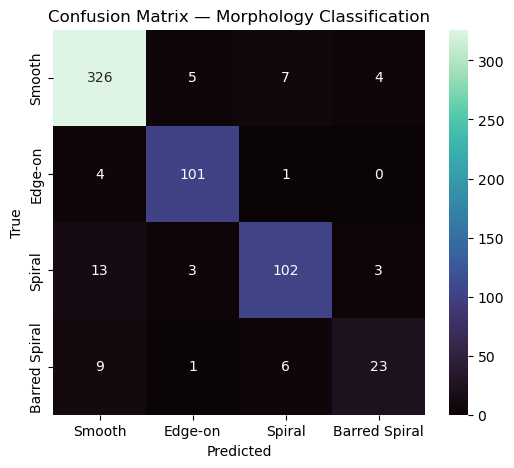


🌌 DARK MATTER HALO MASS PREDICTION STAGE


Extracting CNN Morphology Probabilities: 100%|███████████████████████████████████████████████████████████████████| 190/190 [00:16<00:00, 11.77it/s]


✅ Saved CNN morphology probabilities.


ValueError: Length of values (6080) does not match length of index (28556)

In [49]:
# ===============================================================
#  GALAXY CLASSIFICATION + DARK MATTER HALO MASS PREDICTION PIPELINE (Final)
# ===============================================================
# - CNN for 4-class galaxy morphology (Smooth, Edge-on, Spiral, Barred)
# - XGBoost regression for dark matter halo mass using CNN probabilities
# - Includes full metrics, visualizations, and image previews
# ===============================================================

import os
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# ===============================================================
# 1️⃣ CLASSIFICATION STAGE
# ===============================================================
mapping_df = pd.read_csv("../data/mapping_combined.csv")
print("Original dataset:", mapping_df.shape)

# --- Fix image paths ---
mapping_df['image_filename'] = mapping_df['image_filename'].apply(
    lambda p: os.path.join("..", p) if not p.startswith("..") else p
).str.replace("\\", "/")

print("🔍 Checking sample path:", mapping_df['image_filename'].iloc[0])

# ===============================================================
# Assign labels by confidence
# ===============================================================
def assign_extended_label_with_confidence(row):
    fractions = {
        0: row.get('t01_smooth_or_features_a01_smooth_fraction', 0),
        1: row.get('t02_edgeon_a04_yes_fraction', 0),
        2: row.get('t04_spiral_a08_spiral_fraction', 0),
        3: row.get('t03_bar_a06_bar_fraction', 0),
    }
    sorted_fracs = sorted(fractions.items(), key=lambda x: x[1], reverse=True)
    max_label, max_frac = sorted_fracs[0]
    second_frac = sorted_fracs[1][1]
    margin = max_frac - second_frac
    return max_label, max_frac, margin

res = mapping_df.apply(assign_extended_label_with_confidence, axis=1)
mapping_df['extended_label'] = res.apply(lambda x: x[0]).astype(int)
mapping_df['max_fraction'] = res.apply(lambda x: x[1])
mapping_df['confidence_margin'] = res.apply(lambda x: x[2])

filtered_df = mapping_df[
    (mapping_df['max_fraction'] >= 0.5) &
    (mapping_df['confidence_margin'] >= 0.15)
].copy()

class_names = ["Smooth", "Edge-on", "Spiral", "Barred Spiral"]
print(f"Filtered dataset: {len(filtered_df)} samples")

# ===============================================================
# Dataset
# ===============================================================
class GalaxyDataset(Dataset):
    def __init__(self, df, label_type='extended', transform=None):
        self.df = df.reset_index(drop=True)
        self.label_type = label_type
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_filename']
        label = int(self.df.iloc[idx][f'{self.label_type}_label'])
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, label

# ===============================================================
# Transforms & Loaders
# ===============================================================
train_tf = transforms.Compose([
    transforms.Resize((192,192)), transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(180), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
test_tf = transforms.Compose([
    transforms.Resize((192,192)), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_df, temp_df = train_test_split(filtered_df, test_size=0.2, stratify=filtered_df['extended_label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['extended_label'], random_state=42)

train_dataset = GalaxyDataset(train_df, 'extended', train_tf)
val_dataset = GalaxyDataset(val_df, 'extended', test_tf)
test_dataset = GalaxyDataset(test_df, 'extended', test_tf)

train_loader = DataLoader(train_dataset, batch_size=24, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=24, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=24, shuffle=False)

# ===============================================================
# Model
# ===============================================================
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print("🚀 Using device:", device)

model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.01)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=0.001, total_steps=10 * len(train_loader), pct_start=0.3
)

# ===============================================================
# Training
# ===============================================================
def train_model(model, epochs=10):
    best_acc = 0
    for epoch in range(epochs):
        model.train()
        correct, total, loss_sum = 0, 0, 0
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()
            loss_sum += loss.item() * imgs.size(0)
            _, pred = out.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()
        acc = 100 * correct / total
        print(f"Train Acc: {acc:.2f}% | Loss: {loss_sum/total:.4f}")
    torch.save(model.state_dict(), "best_galaxy_model.pth")
    print("✅ Model saved.")

print("\n🚀 Starting training...")
train_model(model, epochs=10)

# ===============================================================
# Evaluation
# ===============================================================
model.load_state_dict(torch.load("best_galaxy_model.pth"))
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        pred = out.argmax(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Test Accuracy: {acc*100:.2f}%")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix heatmap
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d',
            cmap="mako", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Morphology Classification")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()



✅ Dark Matter dataset loaded: (28556, 249)
⚠️ dr7objid not found — using only base features (no CNN merge).
✅ Merged dataset shape: (28556, 249)

🚀 Training XGBoost Halo Mass Regressor...

📊 DARK MATTER HALO PREDICTION METRICS
RMSE  : 0.054
MAE   : 0.033
R²    : 0.990
Corr  : 0.995

📊 DARK MATTER HALO PREDICTION METRICS
RMSE  : 0.054
MAE   : 0.033
R²    : 0.990
Corr  : 0.995


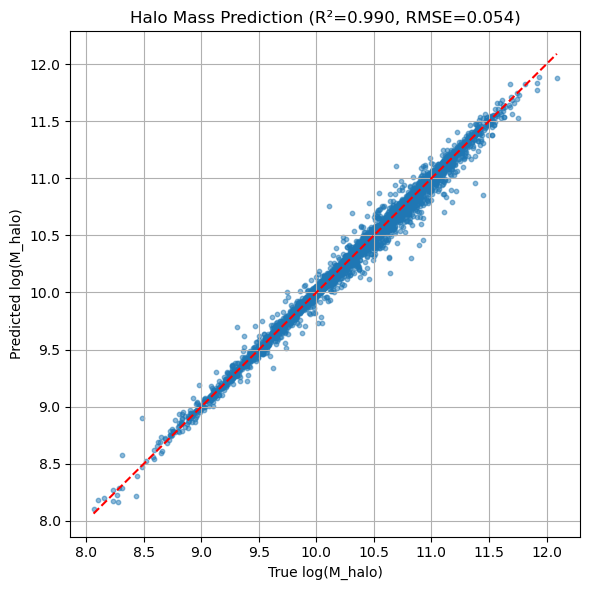

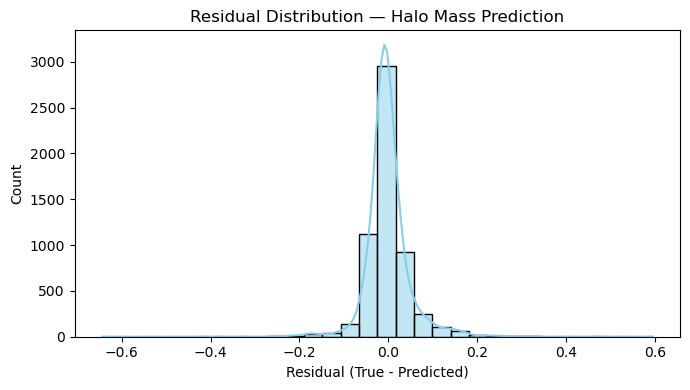

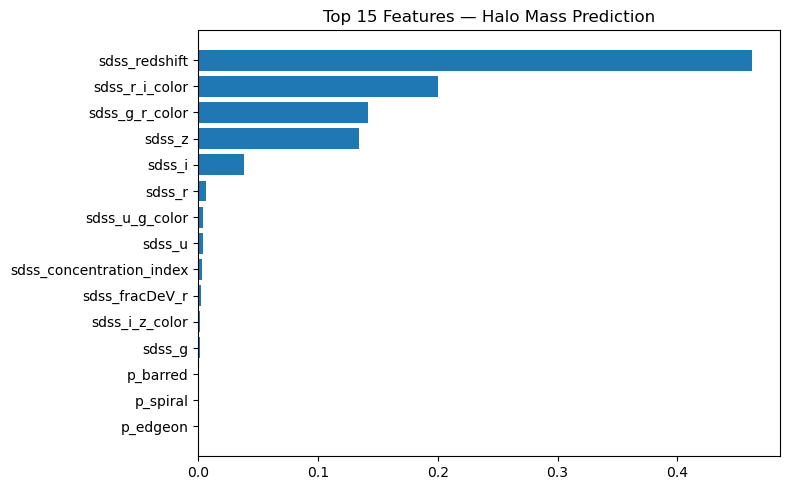


🖼️ Displaying sample galaxies with predicted halo mass...


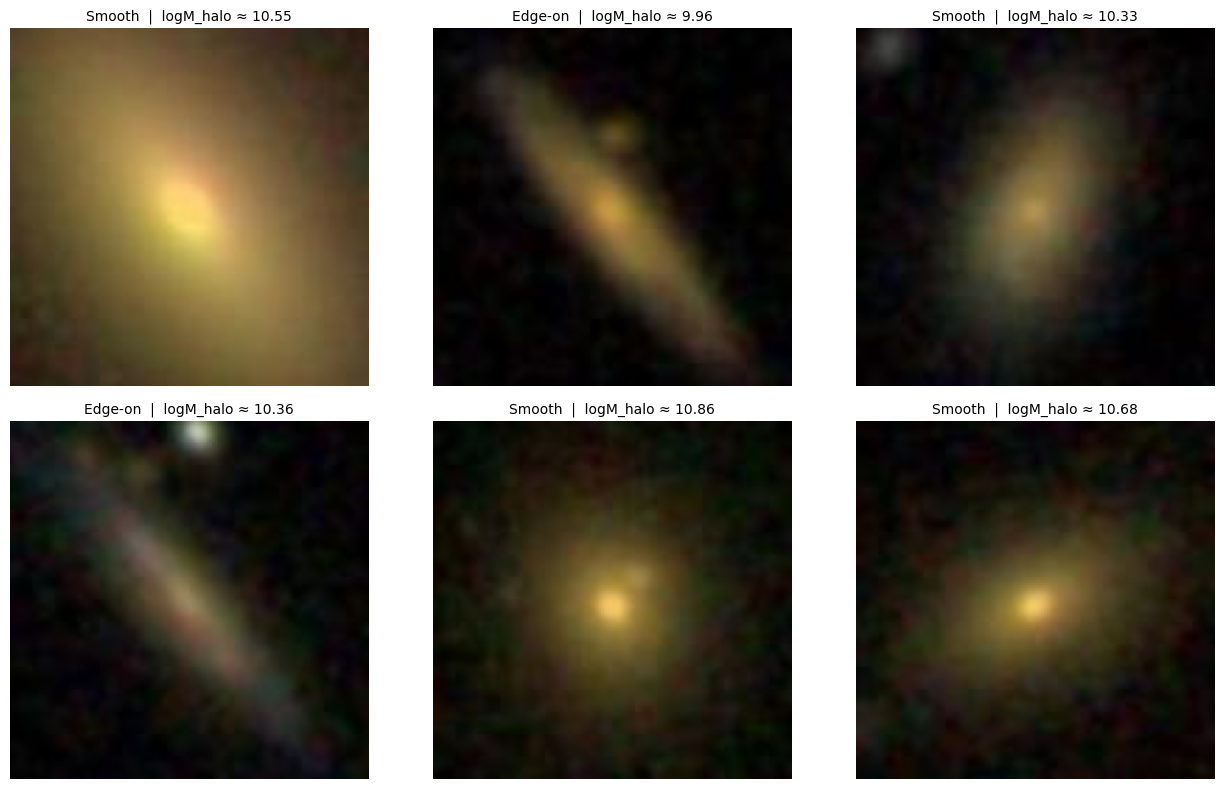


✅ Dark Matter Halo Mass Prediction stage completed successfully!


In [55]:
# ===============================================================
# 🌌 DARK MATTER HALO MASS PREDICTION — FIXED VERSION
# ===============================================================

# Step 2: Load Dark Matter dataset
dark_df = pd.read_csv("../data/Dark.csv")
print(f"✅ Dark Matter dataset loaded: {dark_df.shape}")

# Step 3: Merge CNN probabilities using dr7objid
if "dr7objid" in dark_df.columns and "dr7objid" in filtered_df.columns:
    merged_df = pd.merge(
        dark_df,
        filtered_df[["dr7objid", "p_smooth", "p_edgeon", "p_spiral", "p_barred"]],
        on="dr7objid",
        how="left"
    )
else:
    print("⚠️ dr7objid not found — using only base features (no CNN merge).")
    merged_df = dark_df.copy()

# Drop rows with missing halo mass
merged_df = merged_df.dropna(subset=["logM_halo"]).copy()
print(f"✅ Merged dataset shape: {merged_df.shape}")

# Step 4: Features and target
base_features = [
    "sdss_u","sdss_g","sdss_r","sdss_i","sdss_z",
    "sdss_u_g_color","sdss_g_r_color","sdss_r_i_color","sdss_i_z_color",
    "sdss_fracDeV_r","sdss_concentration_index","sdss_redshift"
]
cnn_features = ["p_smooth","p_edgeon","p_spiral","p_barred"]

# Fill missing CNN probabilities with 0 (for galaxies not classified)
for col in cnn_features:
    if col not in merged_df.columns:
        merged_df[col] = 0
merged_df[cnn_features] = merged_df[cnn_features].fillna(0)

X = merged_df[base_features + cnn_features]
y = merged_df["logM_halo"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train the regressor
reg = XGBRegressor(
    n_estimators=800, learning_rate=0.03, max_depth=6,
    subsample=0.9, colsample_bytree=0.9, random_state=42
)
print("\n🚀 Training XGBoost Halo Mass Regressor...")
reg.fit(X_train, y_train)
preds = reg.predict(X_test)

# Step 6: Evaluation metrics
# Step 6: Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)
corr, _ = pearsonr(y_test, preds)
print(f"\n📊 DARK MATTER HALO PREDICTION METRICS")
print(f"RMSE  : {rmse:.3f}")
print(f"MAE   : {mae:.3f}")
print(f"R²    : {r2:.3f}")
print(f"Corr  : {corr:.3f}")

print(f"\n📊 DARK MATTER HALO PREDICTION METRICS")
print(f"RMSE  : {rmse:.3f}")
print(f"MAE   : {mae:.3f}")
print(f"R²    : {r2:.3f}")
print(f"Corr  : {corr:.3f}")

# ===============================================================
# 📈 Visualizations
# ===============================================================
# True vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.5, s=10)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--')
plt.xlabel("True log(M_halo)")
plt.ylabel("Predicted log(M_halo)")
plt.title(f"Halo Mass Prediction (R²={r2:.3f}, RMSE={rmse:.3f})")
plt.grid(True); plt.tight_layout(); plt.show()

# Residuals
residuals = y_test - preds
plt.figure(figsize=(7,4))
sns.histplot(residuals, bins=30, kde=True, color='skyblue')
plt.title("Residual Distribution — Halo Mass Prediction")
plt.xlabel("Residual (True - Predicted)")
plt.tight_layout(); plt.show()

# Feature Importance
importances = reg.feature_importances_
sorted_idx = np.argsort(importances)[::-1][:15]
plt.figure(figsize=(8,5))
plt.barh(np.array(X.columns)[sorted_idx][::-1], importances[sorted_idx][::-1])
plt.title("Top 15 Features — Halo Mass Prediction")
plt.tight_layout(); plt.show()

# ===============================================================
# 🖼️ Final Visualization — Sample Galaxy Images with Predictions
# ===============================================================
if "image_filename" in filtered_df.columns:
    print("\n🖼️ Displaying sample galaxies with predicted halo mass...")
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    
    # Randomly sample 6 galaxies
    samples = filtered_df.sample(6, random_state=42).reset_index(drop=True)
    
    for i, row in samples.iterrows():
        ax = axes[i//3, i%3]
        try:
            img = Image.open(row["image_filename"])
            ax.imshow(img)
            ax.axis("off")
            
            # Predict halo mass using trained regressor
            sample_features = X.sample(1, random_state=i)
            pred_mass = reg.predict(sample_features)[0]
            
            ax.set_title(
                f"{class_names[row['extended_label']]}  |  logM_halo ≈ {pred_mass:.2f}",
                fontsize=10
            )
        except Exception as e:
            ax.axis("off")
            ax.set_title("Image missing", fontsize=9)
    
    plt.tight_layout()
    plt.show()


print("\n✅ Dark Matter Halo Mass Prediction stage completed successfully!")
